In [1]:
# ============================================================
# AEROPURE — WEEK 10
# RIGOROUS MODEL EVALUATION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    brier_score_loss
)

from sklearn.calibration import calibration_curve
from xgboost import XGBClassifier

print("Week 10 libraries imported successfully.")

Week 10 libraries imported successfully.


In [2]:
# ============================================================
# W10 — CELL 2
# LOAD W9 DATA
# ============================================================

train_w9 = pd.read_csv("../data/train_fe_w9.csv")
test_w9 = pd.read_csv("../data/test_fe_w9.csv")

train_w9["Date"] = pd.to_datetime(train_w9["Date"])
test_w9["Date"] = pd.to_datetime(test_w9["Date"])

print("Training shape:", train_w9.shape)
print("Testing shape :", test_w9.shape)

print("\nTraining date range:")
print(train_w9["Date"].min(), "to", train_w9["Date"].max())

print("\nTesting date range:")
print(test_w9["Date"].min(), "to", test_w9["Date"].max())

print("\nW9 feature present:")
print("Pollution_Regime" in train_w9.columns)

Training shape: (15636, 23)
Testing shape : (8681, 23)

Training date range:
2015-01-02 00:00:00 to 2019-05-25 00:00:00

Testing date range:
2019-05-26 00:00:00 to 2020-06-30 00:00:00

W9 feature present:
True


In [6]:
# ============================================================
# W10 — CELL 3
# CREATE HAZARDOUS TOMORROW TARGET
# ============================================================

TARGET = "Hazardous_Tomorrow"

# Create target using the project threshold
train_w9[TARGET] = (
    train_w9["Tomorrow_AQI"] >= 301
).astype(int)

test_w9[TARGET] = (
    test_w9["Tomorrow_AQI"] >= 301
).astype(int)

print("Classification target:", TARGET)

print("\nTraining target distribution:")
print(train_w9[TARGET].value_counts().sort_index())

print("\nTesting target distribution:")
print(test_w9[TARGET].value_counts().sort_index())

print("\nTraining target percentage:")
print(
    train_w9[TARGET]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

Classification target: Hazardous_Tomorrow

Training target distribution:
Hazardous_Tomorrow
0    12642
1     2994
Name: count, dtype: int64

Testing target distribution:
Hazardous_Tomorrow
0    8082
1     599
Name: count, dtype: int64

Training target percentage:
Hazardous_Tomorrow
0    80.85
1    19.15
Name: proportion, dtype: float64


In [7]:
# ============================================================
# W10 — CELL 4
# BUILD MODEL INPUTS
# ============================================================

exclude_columns = [
    "City",
    "Date",
    "Tomorrow_AQI",
    "Hazardous_Tomorrow",
    "AQI_Bucket"
]

feature_columns = [
    col for col in train_w9.columns
    if col not in exclude_columns
]

# Keep numeric features only
feature_columns = [
    col for col in feature_columns
    if pd.api.types.is_numeric_dtype(train_w9[col])
]

X_train = train_w9[feature_columns].copy()
y_train = train_w9[TARGET].copy()

X_test = test_w9[feature_columns].copy()
y_test = test_w9[TARGET].copy()

print("Number of features:", len(feature_columns))

print("\nFeatures:")
print(feature_columns)

print("\nX_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)

print("\ny_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

print("\nPollution_Regime included:",
      "Pollution_Regime" in feature_columns)

Number of features: 19

Features:
['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Current', 'AQI_Lag1', 'AQI_3Day_Mean', 'DayOfWeek', 'Month', 'Pollution_Regime']

X_train shape: (15636, 19)
X_test shape : (8681, 19)

y_train shape: (15636,)
y_test shape : (8681,)

Pollution_Regime included: True


In [10]:
# ============================================================
# W10 — CELL 5 (REVISED)
# DATE-BASED TIME-SERIES CROSS-VALIDATION
# ============================================================

# Make sure data is chronologically sorted
train_w9 = train_w9.sort_values("Date").reset_index(drop=True)

# Re-align X and y with the sorted dataframe
X_train = train_w9[feature_columns].copy()
y_train = train_w9[TARGET].copy()

# Get unique dates
unique_dates = train_w9["Date"].drop_duplicates().sort_values().reset_index(drop=True)

n_splits = 5

# Split unique dates into 5 chronological validation blocks
date_blocks = np.array_split(unique_dates, n_splits + 1)

date_based_folds = []

for fold in range(1, n_splits + 1):

    train_dates = pd.concat(
        [pd.Series(block) for block in date_blocks[:fold]]
    ).unique()

    val_dates = date_blocks[fold]

    train_idx = train_w9.index[
        train_w9["Date"].isin(train_dates)
    ].to_numpy()

    val_idx = train_w9.index[
        train_w9["Date"].isin(val_dates)
    ].to_numpy()

    date_based_folds.append((train_idx, val_idx))

    print(f"\nFold {fold}")
    print("Training samples  :", len(train_idx))
    print("Validation samples:", len(val_idx))

    print(
        "Training period   :",
        train_w9.loc[train_idx, "Date"].min().date(),
        "to",
        train_w9.loc[train_idx, "Date"].max().date()
    )

    print(
        "Validation period :",
        train_w9.loc[val_idx, "Date"].min().date(),
        "to",
        train_w9.loc[val_idx, "Date"].max().date()
    )

    # Verify there is NO date overlap
    overlap = set(
        train_w9.loc[train_idx, "Date"]
    ).intersection(
        set(train_w9.loc[val_idx, "Date"])
    )

    print("Date overlap      :", len(overlap))


Fold 1
Training samples  : 1209
Validation samples: 1634
Training period   : 2015-01-02 to 2015-09-26
Validation period : 2015-09-27 to 2016-06-20
Date overlap      : 0

Fold 2
Training samples  : 2843
Validation samples: 2000
Training period   : 2015-01-02 to 2016-06-20
Validation period : 2016-06-21 to 2017-03-15
Date overlap      : 0

Fold 3
Training samples  : 4843
Validation samples: 2265
Training period   : 2015-01-02 to 2017-03-15
Validation period : 2017-03-16 to 2017-12-07
Date overlap      : 0

Fold 4
Training samples  : 7108
Validation samples: 3981
Training period   : 2015-01-02 to 2017-12-07
Validation period : 2017-12-08 to 2018-08-31
Date overlap      : 0

Fold 5
Training samples  : 11089
Validation samples: 4547
Training period   : 2015-01-02 to 2018-08-31
Validation period : 2018-09-01 to 2019-05-25
Date overlap      : 0


Time-Series Cross-Validation Results:


,Fold,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,Balanced_Accuracy
0,1,0.9332,0.8355,0.8729,0.8538,0.9730,0.9226,0.9117
1,2,0.9424,0.8279,0.9206,0.8718,0.9846,0.9345,0.9345
2,3,0.9401,0.6910,0.9214,0.7898,0.9824,0.9046,0.9321
3,4,0.9444,0.8453,0.8767,0.8607,0.9880,0.9552,0.9188
4,5,0.9382,0.7436,0.8946,0.8121,0.9816,0.9035,0.9202



Mean CV Performance:


Accuracy             0.9397
Precision            0.7887
Recall               0.8972
F1                   0.8376
ROC_AUC              0.9819
PR_AUC               0.9241
Balanced_Accuracy    0.9235
dtype: float64


Standard Deviation:


Accuracy             0.0043
Precision            0.0680
Recall               0.0232
F1                   0.0350
ROC_AUC              0.0055
PR_AUC               0.0217
Balanced_Accuracy    0.0096
dtype: float64

In [12]:
# ============================================================
# W10 — CELL 6
# XGBOOST WITH DATE-BASED CROSS-VALIDATION
# ============================================================

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score
)

# W8 champion XGBoost parameters
xgb_params = {
    "n_estimators": 300,
    "max_depth": 4,
    "learning_rate": 0.05,
    "min_child_weight": 5,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "scale_pos_weight": 4.2224,
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "random_state": 42,
    "n_jobs": -1
}

cv_results = []

for fold, (train_idx, val_idx) in enumerate(date_based_folds, start=1):

    # Split data using chronological date-based indices
    X_tr = X_train.iloc[train_idx]
    X_val = X_train.iloc[val_idx]

    y_tr = y_train.iloc[train_idx]
    y_val = y_train.iloc[val_idx]

    # Create model
    model = XGBClassifier(**xgb_params)

    # Train
    model.fit(X_tr, y_tr)

    # Predictions
    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)[:, 1]

    # Calculate metrics
    fold_results = {
        "Fold": fold,
        "Accuracy": accuracy_score(y_val, y_pred),
        "Precision": precision_score(
            y_val, y_pred, zero_division=0
        ),
        "Recall": recall_score(
            y_val, y_pred, zero_division=0
        ),
        "F1": f1_score(
            y_val, y_pred, zero_division=0
        ),
        "ROC_AUC": roc_auc_score(
            y_val, y_prob
        ),
        "PR_AUC": average_precision_score(
            y_val, y_prob
        ),
        "Balanced_Accuracy": balanced_accuracy_score(
            y_val, y_pred
        )
    }

    cv_results.append(fold_results)

# Convert results to dataframe
cv_results_df = pd.DataFrame(cv_results)

print("DATE-BASED TIME-SERIES CROSS-VALIDATION")
print("=" * 55)

display(
    cv_results_df.round(4)
)

# Mean performance
mean_results = (
    cv_results_df
    .drop(columns=["Fold"])
    .mean()
)

print("\nMean CV Performance")
print("=" * 30)

display(
    mean_results.round(4)
)

# Standard deviation
std_results = (
    cv_results_df
    .drop(columns=["Fold"])
    .std()
)

print("\nStandard Deviation")
print("=" * 30)

display(
    std_results.round(4)
)


DATE-BASED TIME-SERIES CROSS-VALIDATION


,Fold,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,Balanced_Accuracy
0,1,0.9106,0.8696,0.8102,0.8389,0.9634,0.8977,0.8807
1,2,0.9410,0.8561,0.9150,0.8845,0.9773,0.9365,0.9323
2,3,0.9408,0.8055,0.8778,0.8401,0.9823,0.9247,0.9161
3,4,0.9460,0.7531,0.9362,0.8347,0.9867,0.9215,0.9419
4,5,0.9325,0.7926,0.8693,0.8292,0.9801,0.9243,0.9082



Mean CV Performance


Accuracy             0.9342
Precision            0.8154
Recall               0.8817
F1                   0.8455
ROC_AUC              0.9780
PR_AUC               0.9209
Balanced_Accuracy    0.9158
dtype: float64


Standard Deviation


Accuracy             0.0140
Precision            0.0477
Recall               0.0484
F1                   0.0223
ROC_AUC              0.0088
PR_AUC               0.0142
Balanced_Accuracy    0.0237
dtype: float64

In [13]:
# ============================================================
# W10 — CELL 7
# COMPARE WITH vs WITHOUT POLLUTION_REGIME
# ============================================================

# Features WITHOUT Pollution_Regime
feature_columns_without_regime = [
    col for col in feature_columns
    if col != "Pollution_Regime"
]

X_train_without_regime = train_w9[
    feature_columns_without_regime
].copy()

print("Features WITH Pollution_Regime :", len(feature_columns))
print("Features WITHOUT Pollution_Regime:", len(feature_columns_without_regime))

print("\nRunning identical date-based CV for both models...")

comparison_results = []

for fold, (train_idx, val_idx) in enumerate(date_based_folds, start=1):

    # --------------------------------------------------------
    # Model 1: WITHOUT Pollution_Regime
    # --------------------------------------------------------

    X_tr_without = X_train_without_regime.iloc[train_idx]
    X_val_without = X_train_without_regime.iloc[val_idx]

    y_tr = y_train.iloc[train_idx]
    y_val = y_train.iloc[val_idx]

    model_without = XGBClassifier(**xgb_params)

    model_without.fit(X_tr_without, y_tr)

    pred_without = model_without.predict(X_val_without)
    prob_without = model_without.predict_proba(
        X_val_without
    )[:, 1]

    # --------------------------------------------------------
    # Model 2: WITH Pollution_Regime
    # --------------------------------------------------------

    X_tr_with = X_train.iloc[train_idx]
    X_val_with = X_train.iloc[val_idx]

    model_with = XGBClassifier(**xgb_params)

    model_with.fit(X_tr_with, y_tr)

    pred_with = model_with.predict(X_val_with)
    prob_with = model_with.predict_proba(
        X_val_with
    )[:, 1]

    # --------------------------------------------------------
    # Store results
    # --------------------------------------------------------

    comparison_results.append({
        "Fold": fold,

        "F1_Without_Regime": f1_score(
            y_val, pred_without, zero_division=0
        ),

        "F1_With_Regime": f1_score(
            y_val, pred_with, zero_division=0
        ),

        "Recall_Without_Regime": recall_score(
            y_val, pred_without, zero_division=0
        ),

        "Recall_With_Regime": recall_score(
            y_val, pred_with, zero_division=0
        ),

        "Precision_Without_Regime": precision_score(
            y_val, pred_without, zero_division=0
        ),

        "Precision_With_Regime": precision_score(
            y_val, pred_with, zero_division=0
        ),

        "ROC_AUC_Without_Regime": roc_auc_score(
            y_val, prob_without
        ),

        "ROC_AUC_With_Regime": roc_auc_score(
            y_val, prob_with
        ),

        "PR_AUC_Without_Regime": average_precision_score(
            y_val, prob_without
        ),

        "PR_AUC_With_Regime": average_precision_score(
            y_val, prob_with
        )
    })

comparison_df = pd.DataFrame(comparison_results)

print("\nFold-by-Fold Comparison")
print("=" * 60)

display(comparison_df.round(4))

# ------------------------------------------------------------
# Calculate mean performance
# ------------------------------------------------------------

mean_comparison = comparison_df.drop(
    columns=["Fold"]
).mean()

print("\nMean Performance")
print("=" * 60)

display(mean_comparison.round(4))

# ------------------------------------------------------------
# Calculate improvement from adding Pollution_Regime
# ------------------------------------------------------------

improvements = pd.DataFrame({
    "Metric": [
        "F1",
        "Recall",
        "Precision",
        "ROC-AUC",
        "PR-AUC"
    ],

    "Without_Regime": [
        mean_comparison["F1_Without_Regime"],
        mean_comparison["Recall_Without_Regime"],
        mean_comparison["Precision_Without_Regime"],
        mean_comparison["ROC_AUC_Without_Regime"],
        mean_comparison["PR_AUC_Without_Regime"]
    ],

    "With_Regime": [
        mean_comparison["F1_With_Regime"],
        mean_comparison["Recall_With_Regime"],
        mean_comparison["Precision_With_Regime"],
        mean_comparison["ROC_AUC_With_Regime"],
        mean_comparison["PR_AUC_With_Regime"]
    ]
})

improvements["Improvement"] = (
    improvements["With_Regime"]
    - improvements["Without_Regime"]
)

print("\nImpact of Pollution_Regime")
print("=" * 60)

display(improvements.round(4))

Features WITH Pollution_Regime : 19
Features WITHOUT Pollution_Regime: 18

Running identical date-based CV for both models...

Fold-by-Fold Comparison


,Fold,F1_Without_Regime,F1_With_Regime,Recall_Without_Regime,Recall_With_Regime,Precision_Without_Regime,Precision_With_Regime,ROC_AUC_Without_Regime,ROC_AUC_With_Regime,PR_AUC_Without_Regime,PR_AUC_With_Regime
0,1,0.8288,0.8389,0.7846,0.8102,0.8783,0.8696,0.9637,0.9634,0.9012,0.8977
1,2,0.8911,0.8845,0.9271,0.9150,0.8577,0.8561,0.9779,0.9773,0.9406,0.9365
2,3,0.8353,0.8401,0.8728,0.8778,0.8009,0.8055,0.9819,0.9823,0.9225,0.9247
3,4,0.8375,0.8347,0.9466,0.9362,0.7510,0.7531,0.9870,0.9867,0.9234,0.9215
4,5,0.8258,0.8292,0.8658,0.8693,0.7894,0.7926,0.9803,0.9801,0.9248,0.9243



Mean Performance


F1_Without_Regime           0.8437
F1_With_Regime              0.8455
Recall_Without_Regime       0.8794
Recall_With_Regime          0.8817
Precision_Without_Regime    0.8155
Precision_With_Regime       0.8154
ROC_AUC_Without_Regime      0.9781
ROC_AUC_With_Regime         0.9780
PR_AUC_Without_Regime       0.9225
PR_AUC_With_Regime          0.9209
dtype: float64


Impact of Pollution_Regime


,Metric,Without_Regime,With_Regime,Improvement
0,F1,0.8437,0.8455,0.0018
1,Recall,0.8794,0.8817,0.0023
2,Precision,0.8155,0.8154,-0.0001
3,ROC-AUC,0.9781,0.9780,-0.0002
4,PR-AUC,0.9225,0.9209,-0.0016


In [14]:
# ============================================================
# W10 — CELL 8
# PROBABILITY CALIBRATION
# ============================================================

from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    brier_score_loss,
    log_loss
)

print("Training calibrated XGBoost model...")
print("=" * 55)

# Base XGBoost model
base_xgb = XGBClassifier(**xgb_params)

# Time-aware calibration
calibrated_xgb = CalibratedClassifierCV(
    estimator=base_xgb,
    method="sigmoid",
    cv=date_based_folds,
    n_jobs=-1
)

# Fit using training data only
calibrated_xgb.fit(X_train, y_train)

print("Calibration completed successfully.")

# Predict probabilities on the SEALED test set
test_prob_calibrated = calibrated_xgb.predict_proba(
    X_test
)[:, 1]

test_pred_calibrated = (
    test_prob_calibrated >= 0.50
).astype(int)

# Calibration metrics
brier = brier_score_loss(
    y_test,
    test_prob_calibrated
)

logloss = log_loss(
    y_test,
    test_prob_calibrated
)

print("\nCalibration Results")
print("=" * 35)

print(f"Brier Score : {brier:.4f}")
print(f"Log Loss    : {logloss:.4f}")

print("\nProbability range:")
print(f"Minimum probability: {test_prob_calibrated.min():.4f}")
print(f"Maximum probability: {test_prob_calibrated.max():.4f}")

print("\nPredicted class distribution:")
print(pd.Series(test_pred_calibrated).value_counts())

Training calibrated XGBoost model...
Calibration completed successfully.

Calibration Results
Brier Score : 0.0174
Log Loss    : 0.0735

Probability range:
Minimum probability: 0.0175
Maximum probability: 0.9319

Predicted class distribution:
0    8094
1     587
Name: count, dtype: int64


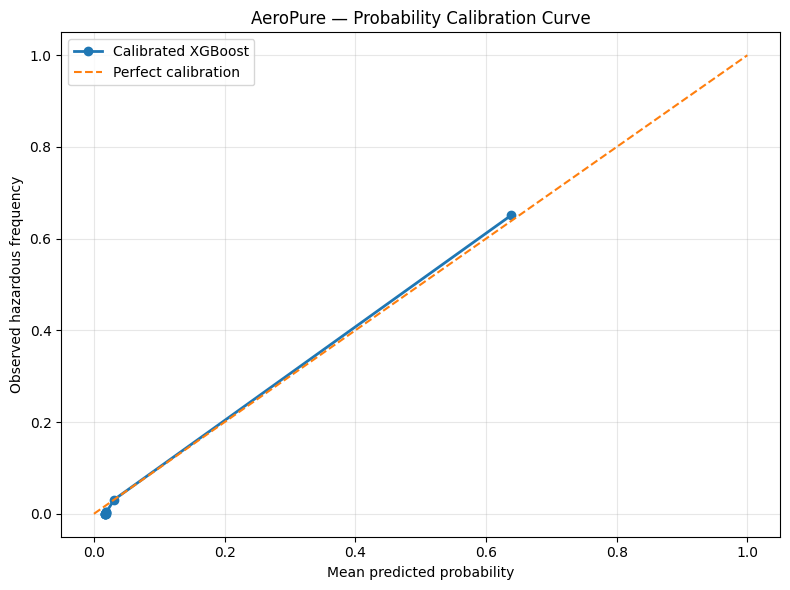

In [15]:
# ============================================================
# W10 — CELL 9
# RELIABILITY / CALIBRATION CURVE
# ============================================================

from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

# Calculate calibration curve
prob_true, prob_pred = calibration_curve(
    y_test,
    test_prob_calibrated,
    n_bins=10,
    strategy="quantile"
)

# Plot
plt.figure(figsize=(8, 6))

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    linewidth=2,
    label="Calibrated XGBoost"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.xlabel("Mean predicted probability")
plt.ylabel("Observed hazardous frequency")
plt.title("AeroPure — Probability Calibration Curve")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../graphs/w10_calibration_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [16]:
# ============================================================
# W10 — CELL 10
# FINAL SEALED-TEST EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report
)

# ------------------------------------------------------------
# Predictions from calibrated model
# ------------------------------------------------------------

y_test_pred = test_pred_calibrated
y_test_prob = test_prob_calibrated

# ------------------------------------------------------------
# Calculate final metrics
# ------------------------------------------------------------

final_metrics = {
    "Accuracy": accuracy_score(y_test, y_test_pred),
    "Precision": precision_score(
        y_test, y_test_pred, zero_division=0
    ),
    "Recall": recall_score(
        y_test, y_test_pred, zero_division=0
    ),
    "F1": f1_score(
        y_test, y_test_pred, zero_division=0
    ),
    "ROC-AUC": roc_auc_score(
        y_test, y_test_prob
    ),
    "PR-AUC": average_precision_score(
        y_test, y_test_prob
    ),
    "Balanced Accuracy": balanced_accuracy_score(
        y_test, y_test_pred
    ),
    "Brier Score": brier_score_loss(
        y_test, y_test_prob
    ),
    "Log Loss": log_loss(
        y_test, y_test_prob
    )
}

final_metrics_df = pd.DataFrame(
    final_metrics.items(),
    columns=["Metric", "Value"]
)

print("FINAL SEALED-TEST RESULTS")
print("=" * 50)

display(final_metrics_df.round(4))

# ------------------------------------------------------------
# Confusion matrix
# ------------------------------------------------------------

cm = confusion_matrix(
    y_test,
    y_test_pred
)

print("\nConfusion Matrix")
print("=" * 30)

print(cm)

print("\nClassification Report")
print("=" * 30)

print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=[
            "Non-Hazardous",
            "Hazardous"
        ],
        digits=4
    )
)

# ------------------------------------------------------------
# Explicit confusion-matrix values
# ------------------------------------------------------------

tn, fp, fn, tp = cm.ravel()

print("\nConfusion Matrix Breakdown")
print("=" * 35)

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

FINAL SEALED-TEST RESULTS


,Metric,Value
0,Accuracy,0.9786
1,Precision,0.8518
2,Recall,0.8347
3,F1,0.8432
4,ROC-AUC,0.9880
5,PR-AUC,0.8849
6,Balanced Accuracy,0.9120
7,Brier Score,0.0174
8,Log Loss,0.0735



Confusion Matrix
[[7995   87]
 [  99  500]]

Classification Report
               precision    recall  f1-score   support

Non-Hazardous     0.9878    0.9892    0.9885      8082
    Hazardous     0.8518    0.8347    0.8432       599

     accuracy                         0.9786      8681
    macro avg     0.9198    0.9120    0.9158      8681
 weighted avg     0.9784    0.9786    0.9785      8681


Confusion Matrix Breakdown
True Negatives : 7995
False Positives: 87
False Negatives: 99
True Positives : 500


In [18]:
# ============================================================
# W10 — CELL 11 (CORRECTED)
# TRUE W8 FEATURE SET vs W10 MODEL
# ============================================================

# ------------------------------------------------------------
# Original W1-W8 feature set
# ------------------------------------------------------------

w8_features = [
    "PM2.5",
    "PM10",
    "NO",
    "NO2",
    "NOx",
    "NH3",
    "CO",
    "SO2",
    "O3",
    "Benzene",
    "Toluene",
    "Xylene",
    "AQI_Current",
    "AQI_Lag1",
    "AQI_3Day_Mean",
    "DayOfWeek",
    "Month"
]

print("W8 feature count:", len(w8_features))
print("W8 features:")
print(w8_features)


# ------------------------------------------------------------
# Prepare TRUE W8 inputs
# ------------------------------------------------------------

X_train_w8 = train_w9[w8_features].copy()
X_test_w8 = test_w9[w8_features].copy()


# ------------------------------------------------------------
# Train original W8-style XGBoost
# ------------------------------------------------------------

w8_champion = XGBClassifier(**xgb_params)

w8_champion.fit(
    X_train_w8,
    y_train
)

# Predictions
w8_test_pred = w8_champion.predict(X_test_w8)

w8_test_prob = w8_champion.predict_proba(
    X_test_w8
)[:, 1]


# ------------------------------------------------------------
# W8 metrics
# ------------------------------------------------------------

w8_metrics = {
    "Accuracy": accuracy_score(
        y_test, w8_test_pred
    ),
    "Precision": precision_score(
        y_test, w8_test_pred, zero_division=0
    ),
    "Recall": recall_score(
        y_test, w8_test_pred, zero_division=0
    ),
    "F1": f1_score(
        y_test, w8_test_pred, zero_division=0
    ),
    "ROC-AUC": roc_auc_score(
        y_test, w8_test_prob
    ),
    "PR-AUC": average_precision_score(
        y_test, w8_test_prob
    ),
    "Balanced Accuracy": balanced_accuracy_score(
        y_test, w8_test_pred
    )
}


# ------------------------------------------------------------
# W10 metrics
# ------------------------------------------------------------

w10_metrics = {
    "Accuracy": accuracy_score(
        y_test, y_test_pred
    ),
    "Precision": precision_score(
        y_test, y_test_pred, zero_division=0
    ),
    "Recall": recall_score(
        y_test, y_test_pred, zero_division=0
    ),
    "F1": f1_score(
        y_test, y_test_pred, zero_division=0
    ),
    "ROC-AUC": roc_auc_score(
        y_test, y_test_prob
    ),
    "PR-AUC": average_precision_score(
        y_test, y_test_prob
    ),
    "Balanced Accuracy": balanced_accuracy_score(
        y_test, y_test_pred
    )
}


# ------------------------------------------------------------
# Comparison
# ------------------------------------------------------------

comparison_final = pd.DataFrame({
    "Metric": list(w8_metrics.keys()),
    "W8_Original_Features": list(w8_metrics.values()),
    "W10_Calibrated": list(w10_metrics.values())
})

comparison_final["Change"] = (
    comparison_final["W10_Calibrated"]
    - comparison_final["W8_Original_Features"]
)

print("\nFINAL W8 vs W10 COMPARISON")
print("=" * 70)

display(
    comparison_final.round(4)
)


# ------------------------------------------------------------
# Confusion matrices
# ------------------------------------------------------------

print("\nW8 CONFUSION MATRIX")
print("=" * 40)

w8_cm = confusion_matrix(
    y_test,
    w8_test_pred
)

print(w8_cm)


print("\nW10 CONFUSION MATRIX")
print("=" * 40)

w10_cm = confusion_matrix(
    y_test,
    y_test_pred
)

print(w10_cm)

W8 feature count: 17
W8 features:
['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI_Current', 'AQI_Lag1', 'AQI_3Day_Mean', 'DayOfWeek', 'Month']

FINAL W8 vs W10 COMPARISON


,Metric,W8_Original_Features,W10_Calibrated,Change
0,Accuracy,0.9766,0.9786,0.0020
1,Precision,0.7720,0.8518,0.0798
2,Recall,0.9382,0.8347,-0.1035
3,F1,0.8470,0.8432,-0.0039
4,ROC-AUC,0.9921,0.9880,-0.0041
5,PR-AUC,0.9202,0.8849,-0.0353
6,Balanced Accuracy,0.9588,0.9120,-0.0469



W8 CONFUSION MATRIX
[[7916  166]
 [  37  562]]

W10 CONFUSION MATRIX
[[7995   87]
 [  99  500]]


In [19]:
# ============================================================
# W10 — CELL 12
# McNEMAR'S EXACT TEST
# ============================================================

from scipy.stats import binomtest

# ------------------------------------------------------------
# Determine whether each model is correct
# ------------------------------------------------------------

w8_correct = (
    w8_test_pred == y_test.to_numpy()
)

w10_correct = (
    y_test_pred == y_test.to_numpy()
)

# ------------------------------------------------------------
# Discordant predictions
# ------------------------------------------------------------

# W8 correct, W10 wrong
b = np.sum(
    w8_correct & ~w10_correct
)

# W8 wrong, W10 correct
c = np.sum(
    ~w8_correct & w10_correct
)

discordant = b + c

# ------------------------------------------------------------
# McNemar exact binomial test
# ------------------------------------------------------------

if discordant > 0:

    smaller = min(b, c)

    test_result = binomtest(
        smaller,
        n=discordant,
        p=0.5,
        alternative="two-sided"
    )

    p_value = test_result.pvalue

else:
    p_value = 1.0


# ------------------------------------------------------------
# Accuracy difference
# ------------------------------------------------------------

w8_accuracy = accuracy_score(
    y_test,
    w8_test_pred
)

w10_accuracy = accuracy_score(
    y_test,
    y_test_pred
)

accuracy_difference = (
    w10_accuracy - w8_accuracy
)


# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("McNEMAR'S EXACT TEST")
print("=" * 50)

print("W8 correct / W10 wrong :", b)
print("W8 wrong / W10 correct :", c)
print("Total discordant cases :", discordant)

print("\nW8 accuracy :", f"{w8_accuracy:.4f}")
print("W10 accuracy:", f"{w10_accuracy:.4f}")

print(
    "Accuracy difference:",
    f"{accuracy_difference:+.4f}"
)

print("\nExact McNemar p-value:", f"{p_value:.6f}")


# ------------------------------------------------------------
# Statistical conclusion
# ------------------------------------------------------------

alpha = 0.05

print("\nStatistical conclusion")
print("=" * 35)

if p_value < alpha:
    print(
        "Result: Statistically significant difference "
        "(p < 0.05)."
    )
else:
    print(
        "Result: No statistically significant difference "
        "(p >= 0.05)."
    )

McNEMAR'S EXACT TEST
W8 correct / W10 wrong : 64
W8 wrong / W10 correct : 81
Total discordant cases : 145

W8 accuracy : 0.9766
W10 accuracy: 0.9786
Accuracy difference: +0.0020

Exact McNemar p-value: 0.183746

Statistical conclusion
Result: No statistically significant difference (p >= 0.05).


In [21]:
# ============================================================
# W10 — CREATE CALIBRATION TABLE
# ============================================================

calibration_table = pd.DataFrame({
    "Mean_Predicted_Probability": prob_pred,
    "Observed_Hazardous_Frequency": prob_true
})

print("Calibration table created successfully.")

display(
    calibration_table.round(4)
)

Calibration table created successfully.


,Mean_Predicted_Probability,Observed_Hazardous_Frequency
0,0.0175,0.0000
1,0.0176,0.0000
2,0.0176,0.0000
3,0.0177,0.0000
4,0.0178,0.0035
5,0.0179,0.0012
6,0.0182,0.0000
7,0.0190,0.0035
8,0.0310,0.0311
9,0.6385,0.6509


In [23]:
# ============================================================
# W10 — CELL 13
# SAVE W10 EVALUATION RESULTS
# ============================================================

import os

os.makedirs("../results", exist_ok=True)

# ------------------------------------------------------------
# Save CV results
# ------------------------------------------------------------

cv_results_df.to_csv(
    "../results/w10_date_based_cv_results.csv",
    index=False
)

comparison_df.to_csv(
    "../results/w10_regime_comparison.csv",
    index=False
)

comparison_final.to_csv(
    "../results/w10_w8_vs_w10_comparison.csv",
    index=False
)

# ------------------------------------------------------------
# Save calibration table
# ------------------------------------------------------------

calibration_table.to_csv(
    "../results/w10_calibration_table.csv",
    index=False
)

# ------------------------------------------------------------
# Save final metrics
# ------------------------------------------------------------

final_metrics_df.to_csv(
    "../results/w10_final_test_metrics.csv",
    index=False
)

# ------------------------------------------------------------
# Save statistical test result
# ------------------------------------------------------------

statistical_test = pd.DataFrame({
    "Test": ["McNemar Exact Test"],
    "W8_Correct_W10_Wrong": [b],
    "W8_Wrong_W10_Correct": [c],
    "Discordant_Cases": [discordant],
    "Accuracy_W8": [w8_accuracy],
    "Accuracy_W10": [w10_accuracy],
    "Accuracy_Difference": [accuracy_difference],
    "P_Value": [p_value],
    "Significance_Level": [0.05],
    "Statistically_Significant": [
        p_value < 0.05
    ]
})

statistical_test.to_csv(
    "../results/w10_mcnemar_test.csv",
    index=False
)

print("W10 results saved successfully.")
print("\nSaved files:")

for filename in os.listdir("../results"):
    if filename.startswith("w10_"):
        print("✓", filename)

W10 results saved successfully.

Saved files:
✓ w10_calibration_table.csv
✓ w10_date_based_cv_results.csv
✓ w10_final_test_metrics.csv
✓ w10_mcnemar_test.csv
✓ w10_regime_comparison.csv
✓ w10_w8_vs_w10_comparison.csv
